In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('housing_data_after_handling_missing_value.csv')

In [4]:
df.head()

,url,image_url,beds,baths,sqft,address,property_type,region,parking_total_spaces,walk_score,middle_school_distance,wind_risk,nearby_cities,sqft_lot_category,zip_code,property_age,mobility_score,avg_school_distance_miles,parking_quality_score,has_garage,county,zip_price_tier,price_volatility,price_reduction_total,price
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"197 Lowell St, Arlington, MA 02474",single family,Arlington,4.0,81.0,0.4,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,2474,145.0,73.0,0.900,0.0,0,Middlesex,Mid-tier,190775.778337,481500.0,999000
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"225 Mystic St, Arlington, MA 02474",single family,Arlington,3.0,69.0,0.1,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,2474,145.0,65.0,0.300,1.0,0,Middlesex,Mid-tier,75258.487893,189000.0,799000
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"43 Longmeadow Rd, Arlington, MA 02474",single family,Arlington,5.0,32.0,0.2,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,2474,73.0,33.2,3.400,0.0,0,Middlesex,Mid-tier,379500.000000,759000.0,899000
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"11 Pine Ct, Arlington, MA 02476",single family,Arlington,2.0,84.0,0.7,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,2476,99.0,72.0,0.700,0.0,0,Middlesex,Mid-tier,358034.448994,815000.0,998000
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,"17 Norcross St FLOOR 3, Arlington, MA 02474",condo,Arlington,1.0,77.0,0.1,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Unknown,2474,117.0,84.6,1.733,1.0,0,Middlesex,Mid-tier,16004.999219,-47000.0,668000


# Feature Selection

In [5]:
# data -> df with dropped cols

train_data = pd.read_csv('housing_data_after_handling_missing_value.csv').drop(columns={'url','image_url','address','nearby_cities','region'})

In [6]:
train_data.head()

,beds,baths,sqft,property_type,parking_total_spaces,walk_score,middle_school_distance,wind_risk,sqft_lot_category,zip_code,property_age,mobility_score,avg_school_distance_miles,parking_quality_score,has_garage,county,zip_price_tier,price_volatility,price_reduction_total,price
0,3.0,2.0,1415.0,single family,4.0,81.0,0.4,6.0,Ultra Compact,2474,145.0,73.0,0.900,0.0,0,Middlesex,Mid-tier,190775.778337,481500.0,999000
1,2.0,1.0,1064.0,single family,3.0,69.0,0.1,6.0,Ultra Compact,2474,145.0,65.0,0.300,1.0,0,Middlesex,Mid-tier,75258.487893,189000.0,799000
2,2.0,1.0,1628.0,single family,5.0,32.0,0.2,6.0,Ultra Compact,2474,73.0,33.2,3.400,0.0,0,Middlesex,Mid-tier,379500.000000,759000.0,899000
3,3.0,2.0,1824.0,single family,2.0,84.0,0.7,6.0,Ultra Compact,2476,99.0,72.0,0.700,0.0,0,Middlesex,Mid-tier,358034.448994,815000.0,998000
4,2.0,2.0,1221.0,condo,1.0,77.0,0.1,6.0,Unknown,2474,117.0,84.6,1.733,1.0,0,Middlesex,Mid-tier,16004.999219,-47000.0,668000


In [7]:
train_data['zip_code'].unique().shape # decided to drop this col too.

(471,)

In [8]:
train_data = pd.read_csv('housing_data_after_handling_missing_value.csv').drop(columns={'url','image_url','address','nearby_cities','region','zip_code'})

In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7792 entries, 0 to 7791
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   beds                       7792 non-null   float64
 1   baths                      7792 non-null   float64
 2   sqft                       7792 non-null   float64
 3   property_type              7792 non-null   object 
 4   parking_total_spaces       7792 non-null   float64
 5   walk_score                 7792 non-null   float64
 6   middle_school_distance     7792 non-null   float64
 7   wind_risk                  7792 non-null   float64
 8   sqft_lot_category          7792 non-null   object 
 9   property_age               7792 non-null   float64
 10  mobility_score             7792 non-null   float64
 11  avg_school_distance_miles  7792 non-null   float64
 12  parking_quality_score      7792 non-null   float64
 13  has_garage                 7792 non-null   int64

In [10]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_data.copy()

categorical_cols = train_data.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['condo', 'single family', 'townhouse'], dtype=object)]
[array(['Rural/Estate', 'Suburban Large', 'Suburban Medium',
       'Suburban Small', 'Ultra Compact', 'Unknown'], dtype=object)]
[array(['Barnstable', 'Berkshire', 'Bristol', 'Dukes', 'Essex', 'Franklin',
       'Hampden', 'Hampshire', 'Middlesex', 'Nantucket', 'Norfolk',
       'Other', 'Plymouth', 'Suffolk', 'Worcester'], dtype=object)]
[array(['Budget', 'High-end', 'Mid-tier'], dtype=object)]


In [11]:
X_label

,beds,baths,sqft,property_type,parking_total_spaces,walk_score,middle_school_distance,wind_risk,sqft_lot_category,property_age,mobility_score,avg_school_distance_miles,parking_quality_score,has_garage,county,zip_price_tier,price_volatility,price_reduction_total
0,3.0,2.0,1415.0,1.0,4.0,81.0,0.4,6.0,4.0,145.0,73.0,0.900,0.0,0,8.0,2.0,190775.778337,481500.0
1,2.0,1.0,1064.0,1.0,3.0,69.0,0.1,6.0,4.0,145.0,65.0,0.300,1.0,0,8.0,2.0,75258.487893,189000.0
2,2.0,1.0,1628.0,1.0,5.0,32.0,0.2,6.0,4.0,73.0,33.2,3.400,0.0,0,8.0,2.0,379500.000000,759000.0
3,3.0,2.0,1824.0,1.0,2.0,84.0,0.7,6.0,4.0,99.0,72.0,0.700,0.0,0,8.0,2.0,358034.448994,815000.0
4,2.0,2.0,1221.0,0.0,1.0,77.0,0.1,6.0,5.0,117.0,84.6,1.733,1.0,0,8.0,2.0,16004.999219,-47000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7787,10.0,4.0,3150.0,1.0,4.0,74.0,0.4,6.0,4.0,121.0,65.2,3.700,4.0,1,6.0,0.0,184596.125095,370150.0
7788,2.0,1.0,768.0,1.0,2.0,59.0,0.3,5.0,4.0,75.0,54.2,2.650,2.5,1,6.0,0.0,51047.428926,109000.0
7789,3.0,1.0,966.0,1.0,4.0,17.0,0.3,5.0,2.0,69.0,21.8,0.600,1.0,0,6.0,0.0,4898.979486,-10000.0
7790,3.0,1.0,1136.0,1.0,4.0,64.0,0.4,6.0,4.0,69.0,57.2,1.500,0.0,0,6.0,0.0,0.000000,0.0


In [12]:
y_label

,price
0,999000
1,799000
2,899000
3,998000
4,668000
...,...
7787,439900
7788,229000
7789,289900
7790,207400


# Technique 1 - Correlation Analysis



<Axes: >

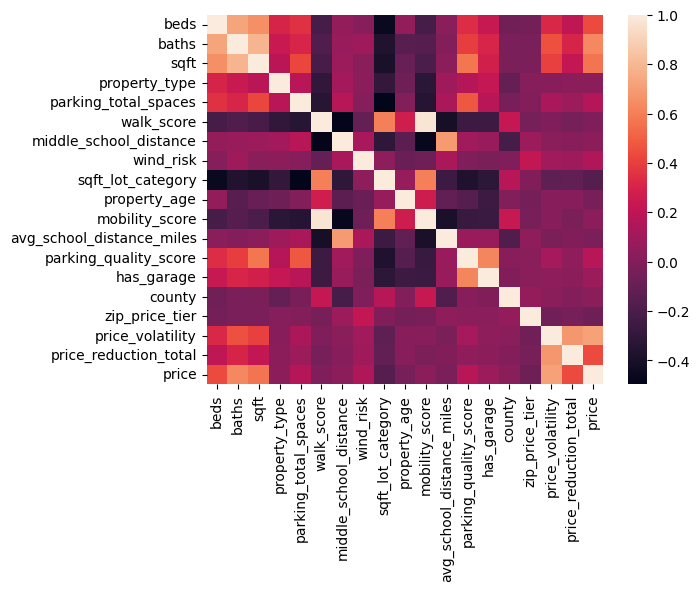

In [13]:
sns.heatmap(data_label_encoded.corr())

In [14]:
# t1 -> technique 1
t1_df = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
t1_df

,feature,corr_coeff
0,baths,0.629975
1,sqft,0.564692
2,property_type,0.027342
3,parking_total_spaces,0.171763
4,walk_score,-0.015410
5,middle_school_distance,0.029270
6,wind_risk,0.154905
7,sqft_lot_category,-0.163753
8,property_age,-0.043018
9,mobility_score,0.023242


#Technique 2 - Random Forest Feature Importance

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
# training the RF model
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label,y_label)

# extracting feature importance scores
t2_df = pd.DataFrame({
    'feature': X_label.columns,
    'Random Forest Importance': rf_label.feature_importances_
}).sort_values(by='Random Forest Importance', ascending = False)

t2_df

,feature,Random Forest Importance
16,price_volatility,0.378576
1,baths,0.282595
17,price_reduction_total,0.064633
2,sqft,0.061252
3,property_type,0.034433
5,walk_score,0.025693
4,parking_total_spaces,0.023294
10,mobility_score,0.019033
11,avg_school_distance_miles,0.017490
15,zip_price_tier,0.016809


#Technique 3 - Gradient Boosting Feature importances

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

In [18]:
# Trainig the model
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label,y_label)

GradientBoostingRegressor()

In [19]:
t3_df = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

t3_df

,feature,gb_importance
16,price_volatility,0.404130
1,baths,0.298382
2,sqft,0.086359
3,property_type,0.055093
17,price_reduction_total,0.053777
4,parking_total_spaces,0.022797
15,zip_price_tier,0.016584
10,mobility_score,0.013733
7,wind_risk,0.011787
5,walk_score,0.010608


#Technique 4 - Permutation Importance

In [20]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
t4_df = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

t4_df

,feature,permutation_importance
1,baths,0.486110
16,price_volatility,0.331080
3,property_type,0.210048
15,zip_price_tier,0.033624
17,price_reduction_total,0.031568
5,walk_score,0.027485
10,mobility_score,0.014609
2,sqft,0.013007
14,county,0.009973
12,parking_quality_score,0.008508


#Technique 5 - LASSO

In [21]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled,y_label)

t5_df = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

t5_df

,feature,lasso_coeff
16,price_volatility,1.267364e+06
1,baths,6.860448e+05
10,mobility_score,5.471970e+05
2,sqft,4.457874e+05
7,wind_risk,1.931424e+05
6,middle_school_distance,7.438733e+04
13,has_garage,3.418037e+04
14,county,3.165081e+04
4,parking_total_spaces,2.665256e+04
9,property_age,-1.178871e+04


# Technique 6 - RFE

In [22]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
t6_df = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

t6_df

,feature,rfe_score
16,price_volatility,0.395168
1,baths,0.270924
17,price_reduction_total,0.062092
2,sqft,0.059644
3,property_type,0.031985
5,walk_score,0.027563
4,parking_total_spaces,0.023835
10,mobility_score,0.018277
15,zip_price_tier,0.017203
11,avg_school_distance_miles,0.016624


#Technique 7 - Linear Regression Weights

In [23]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
t7_df = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

t7_df

,feature,reg_coeffs
16,price_volatility,1.267364e+06
1,baths,6.860448e+05
10,mobility_score,5.471974e+05
2,sqft,4.457875e+05
7,wind_risk,1.931424e+05
6,middle_school_distance,7.438736e+04
13,has_garage,3.418041e+04
14,county,3.165082e+04
4,parking_total_spaces,2.665259e+04
9,property_age,-1.178871e+04


In [25]:
final_t_df = t1_df.merge(t2_df,on='feature').merge(t3_df,on='feature').merge(t4_df,on='feature').merge(t5_df,on='feature').merge(t6_df,on='feature').merge(t7_df,on='feature').set_index('feature')

In [27]:
final_t_df

,corr_coeff,Random Forest Importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
baths,0.629975,0.282595,0.298382,0.486110,6.860448e+05,0.270924,6.860448e+05
sqft,0.564692,0.061252,0.086359,0.013007,4.457874e+05,0.059644,4.457875e+05
property_type,0.027342,0.034433,0.055093,0.210048,-1.052190e+05,0.031985,-1.052190e+05
parking_total_spaces,0.171763,0.023294,0.022797,-0.005171,2.665256e+04,0.023835,2.665259e+04
walk_score,-0.015410,0.025693,0.010608,0.027485,-3.844997e+05,0.027563,-3.845001e+05
middle_school_distance,0.029270,0.010101,0.004240,0.001330,7.438733e+04,0.012333,7.438736e+04
wind_risk,0.154905,0.006242,0.011787,0.003053,1.931424e+05,0.005629,1.931424e+05
sqft_lot_category,-0.163753,0.006237,0.000490,0.003258,-1.451932e+04,0.005196,-1.451934e+04
property_age,-0.043018,0.012571,0.001067,0.001217,-1.178871e+04,0.014846,-1.178871e+04


In [30]:
final_t_df[['corr_coeff','Random Forest Importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)


,0
feature,
price_volatility,0.445513
baths,0.393597
sqft,0.156991
price_reduction_total,0.129976
property_type,0.071780
parking_total_spaces,0.047304
parking_quality_score,0.043426
wind_risk,0.036323
has_garage,0.018018


In [34]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=200, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=10, scoring='r2')

scores.mean()

np.float64(0.427966849121582)

In [41]:
features_to_remove = [
    'sqft_lot_category',      # -0.029714 (negative!)
    'property_age',           # -0.002663 (negative!)
    'avg_school_distance_miles',  # 0.000224 (tiny)
    'zip_price_tier'          # 0.000815 (very low)
]

df.drop(columns=features_to_remove, inplace=True)

In [42]:
df.shape

(7792, 21)

In [43]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'address', 'property_type',
       'region', 'parking_total_spaces', 'walk_score',
       'middle_school_distance', 'wind_risk', 'nearby_cities', 'zip_code',
       'mobility_score', 'parking_quality_score', 'has_garage', 'county',
       'price_volatility', 'price_reduction_total', 'price'],
      dtype='object')

In [44]:
df.to_csv('housing_data_after_feature_selection.csv')